In [1]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import yfinance as yf
import pandas as pd

In [2]:
tickers = ['^GSPC','^IXIC','^DJI','CL=F']
display_name = {'^GSPC':'S&P 500','^IXIC':'NASDAQ','^DJI' :'Dow','CL=F': 'Oil(WTI)'}

# Download historical index data
data  = yf.download(tickers, start="2026-02-01")
data = data.dropna()
data = ((data-data.iloc[0])/data.iloc[0])*100
data = data.Close.round(2).reset_index()

#get event data
events = pd.read_csv("iran_events.csv")
events.date = pd.to_datetime(events.date)

#merge data and events
data_file = data.merge(events, left_on='Date',right_on='date',how='left')
data_file['date'] = data_file.Date.dt.strftime('%b %d') 

[*********************100%***********************]  4 of 4 completed


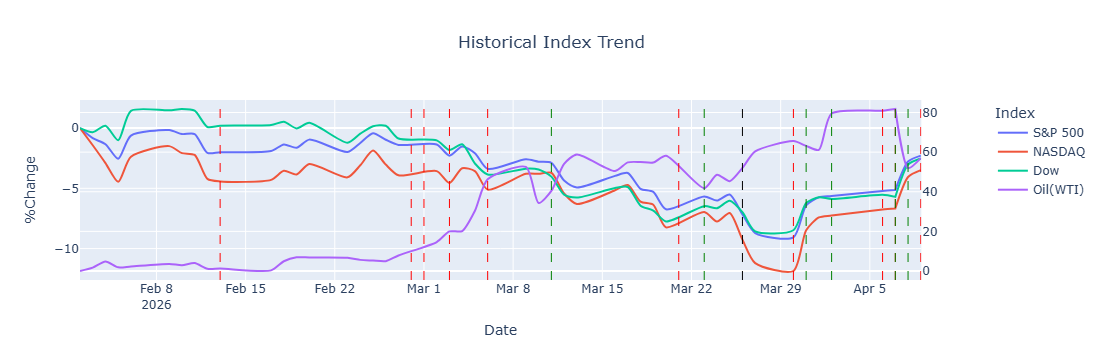

In [3]:
# Create figure with secondary y-axis
fig = make_subplots(specs=[[{"secondary_y": True}]])


for ticker in tickers:
    secondary_y = True if ticker == 'CL=F' else False 
    fig.add_trace(go.Scatter(x=data_file.Date, y=data_file[ticker],
                            name=display_name[ticker],
                             line_shape='spline',  # Sets the line to spline shape
                             line=dict(smoothing=0.7), # Adjusts the smoothness (0 to 1.3)
                             customdata = data_file[["date","event"]].fillna(''),
                            hovertemplate="Date:%{customdata[0]}<br>%{customdata[1]}<br>%{y}"),
                  secondary_y=secondary_y
                 )
for date,event_type,event in zip(events.date,events.type,events.event):
    if event_type == 'escalation':
        color = 'red'
    elif event_type == 'de-escalation':
        color = 'green'
    else:
        color = 'black'
        
    fig.add_vline(x=date, line_width = 1, line_dash = 'dash', line_color = color)

    
fig.update_layout(legend_title_text = "Index",
                  title={
                      'text': "Historical Index Trend",
                      'y': 0.9,
                      'x': 0.5,
                      'xanchor': 'center',
                      'yanchor': 'top'
                  }
                 )
fig.update_xaxes(title_text="Date")
fig.update_yaxes(title_text="%Change", secondary_y=False)
fig.show()